# 05. ComprasNet 보정 분포·공급자 구조 분석

04의 processed Parquet만 사용해 합성 시뮬레이션 보정 후보를 만든다. 직접 관측값,
계산 대리변수, 별도 시나리오 값을 구분한다. 관측된 재등장은 진정한 잔존·이탈과 같지 않으며,
기간 중 적합한 입찰기회가 없었을 수도 있다.

In [1]:
# 프로젝트 루트를 찾아 상대경로와 로컬 모듈 import를 일관되게 사용한다.
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("프로젝트 루트를 찾을 수 없습니다. 저장소 안에서 노트북을 실행하세요.")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
SEED = 20260826
PROJECT_ROOT

WindowsPath('D:/CODE/proj2/5pl')

In [2]:
# processed 입력과 출력 경로를 확인하고 필요한 파일이 없으면 중단한다.
import json
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.dataframe as dd
import networkx as nx
from scipy import stats
from IPython.display import display

PROCESSED = PROJECT_ROOT / "data" / "processed" / "comprasnet"
FIGURES = PROJECT_ROOT / "outputs" / "figures" / "comprasnet"
FIGURES.mkdir(parents=True, exist_ok=True)
required = [PROCESSED / "auctions.parquet", PROCESSED / "items.parquet", PROCESSED / "supplier_item_events"]
missing = [str(path.relative_to(PROJECT_ROOT)) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("04 노트북의 processed 산출물이 없습니다: " + ", ".join(missing))
auctions = pd.read_parquet(PROCESSED / "auctions.parquet")
items = pd.read_parquet(PROCESSED / "items.parquet")
items_valid = items.loc[items["is_valid_analysis_sample"]].copy()
events = dd.read_parquet(PROCESSED / "supplier_item_events", engine="pyarrow")
events = events.drop_duplicates(subset=["event_id"])
print("auctions", len(auctions), "items", len(items), "valid items", len(items_valid), "event partitions", events.npartitions)

auctions 170096 items 1365244 valid items 1350915 event partitions 169


C:\Users\Jiyoon\AppData\Local\Temp\ipykernel_28384\2466520710.py:8: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  ax.tick_params(axis="x", rotation=90); plt.tight_layout(); plt.savefig(FIGURES / "period_auction_counts.png", dpi=150); plt.show()
C:\Users\Jiyoon\AppData\Local\Temp\ipykernel_28384\2466520710.py:8: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  ax.tick_params(axis="x", rotation=90); plt.tight_layout(); plt.savefig(FIGURES / "period_auction_counts.png", dpi=150); plt.show()
C:\Users\Jiyoon\AppData\Local\Temp\ipykernel_28384\2466520710.py:8: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  ax.tick_params(axis="x", rotation=90); plt.tight_layout(); plt.savefig(FIGURES / "period_auction_counts.png", dpi=150); plt.show()
C:\Users\Jiyoon\AppData\Local\Temp\ipykernel_28384\2466520710.py:8: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) De

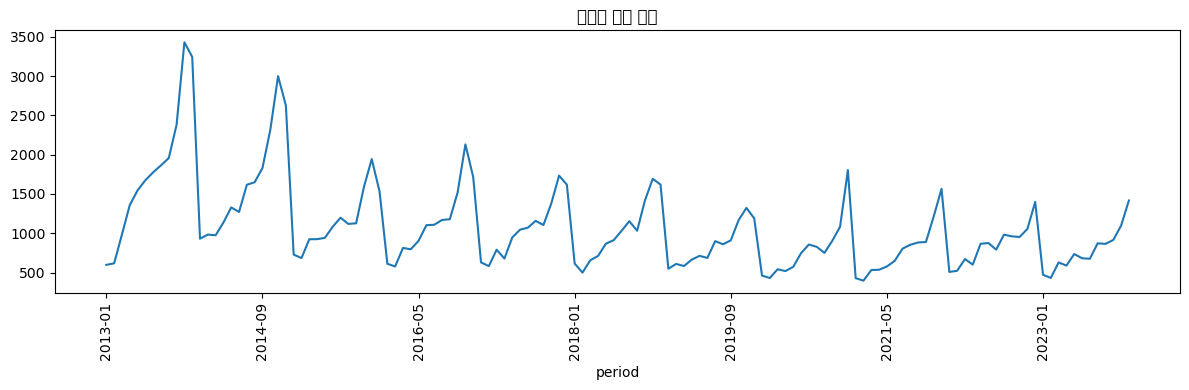

,period,auction_count
0,2013-01,598
1,2013-02,618
2,2013-03,985
3,2013-04,1358
4,2013-05,1546


,item_group_count
count,149137.000000
mean,3.505984
std,8.241611
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,265.000000


In [3]:
# 기간별 조달 건수와 조달 건별 임시 품목군 수를 계산하고 저장한다.
period_auctions = (auctions.loc[auctions["is_valid_analysis_sample"]].groupby("period")["auction_id"].nunique()
                   .rename("auction_count").reset_index().sort_values("period"))
items_per_auction = (items_valid.groupby("auction_id")["item_group"].nunique().rename("item_group_count").reset_index())
period_auctions.to_csv(PROCESSED / "summary_period_auctions.csv", index=False, encoding="utf-8-sig")
items_per_auction.describe().to_csv(PROCESSED / "summary_items_per_auction.csv", encoding="utf-8-sig")
ax = period_auctions.plot(x="period", y="auction_count", figsize=(12, 4), legend=False, title="기간별 조달 건수")
ax.tick_params(axis="x", rotation=90); plt.tight_layout(); plt.savefig(FIGURES / "period_auction_counts.png", dpi=150); plt.show()
display(period_auctions.head())
display(items_per_auction.describe())

In [4]:
# 조달 건 내 임시 품목군 조합과 자주 함께 등장하는 쌍을 계산한다.
bundle_groups = items_valid[["auction_id", "item_group"]].drop_duplicates().groupby("auction_id")["item_group"].agg(list)
pair_counts = {}
skipped_large_bundles = 0
for groups in bundle_groups:
    unique_groups = sorted(set(groups))
    if len(unique_groups) > 30:
        skipped_large_bundles += 1
        continue
    for pair in itertools.combinations(unique_groups, 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1
cooccurrence = pd.DataFrame([(a, b, count) for (a, b), count in pair_counts.items()],
                            columns=["item_group_a", "item_group_b", "cooccurrence_count"]).sort_values("cooccurrence_count", ascending=False)
cooccurrence.head(1000).to_csv(PROCESSED / "summary_item_cooccurrence.csv", index=False, encoding="utf-8-sig")
print("조합폭발 방지를 위해 제외한 30개 초과 묶음:", skipped_large_bundles)
display(cooccurrence.head(20))

조합폭발 방지를 위해 제외한 30개 초과 묶음: 2834


,item_group_a,item_group_b,cooccurrence_count
1904,G_0535aed4c46d,G_7071f412b6cd,861
7195,G_aad17919aa90,G_d08c9d7054a2,797
165,G_59eef3165a9c,G_d2bebba8b00f,524
6779,G_ab1e4288ca3f,G_d9d1d054ee05,363
6713,G_7eaf33ad0794,G_b7d19f6067e4,357
1008,G_7071f412b6cd,G_bd29ef8dcd01,347
25462,G_36bd89cdbeef,G_7c5a7c4a5c06,333
6766,G_060bf12d24d1,G_69d58df3a6e3,329
8745,G_14ff91cfb2c9,G_d7e4720cf10c,324
8175,G_8b6991fa23b9,G_b7d19f6067e4,318


In [5]:
# 품목군별 수량·총금액·단가와 참여 공급자 수를 집계한다.
item_base = (items_valid.groupby("item_group").agg(
    item_rows=("item_id", "nunique"), auctions=("auction_id", "nunique"),
    quantity_median=("item_quantity", "median"), quantity_mean=("item_quantity", "mean"),
    total_value_median=("item_total_value", "median"), unit_price_median=("unit_price", "median"),
    description_example=("item_description", "first"),
).reset_index())
suppliers_per_item = (events.groupby("item_group")["supplier_id"].nunique().compute().rename("supplier_count").reset_index())
item_summary = item_base.merge(suppliers_per_item, on="item_group", how="left")
item_summary.to_csv(PROCESSED / "summary_item_groups.csv", index=False, encoding="utf-8-sig")
display(item_summary.sort_values(["auctions", "supplier_count"], ascending=False).head(20))

,item_group,item_rows,auctions,quantity_median,quantity_mean,total_value_median,unit_price_median,description_example,supplier_count
477,G_0a8d49b1edef,10500,4183,1.0,17903.775714,44369.96,22900.0,MANUTENCAO / REFORMA PREDIAL,9127.0
10811,G_e28f35e365ee,6314,3799,1.0,1310.298226,103174.035,83950.0,SERVICO ENGENHARIA,7793.0
6012,G_7eaf33ad0794,8326,3419,2.0,1595.901033,128423.2,44040.8,PRESTACAO DE SERVICOS DE APOIO ADMINISTRATIVO,7248.0
9240,G_c1c6226abd15,5546,2635,3.0,20074.661918,98357.935,31794.0,PRESTACAO DE SERVICO DE LIMPEZA E CONSERVACAO ...,6462.0
8752,G_b7d19f6067e4,4429,2296,2.0,11.98284,89067.62,34984.9,PRESTACAO DE SERVICOS DE PORTARIA / RECEPCAO,6166.0
2517,G_3558a908871f,4276,1733,7.0,7883.653648,76302.84,26374.05,SERVICO ESPECIALIZADO DE LIMPEZA,5516.0
2819,G_3bba032740eb,3802,1586,4.0,156.258548,11999.935,3491.16,"INSTALACAO / MANUTENCAO - ELEVADORES, ESCADAS ...",699.0
11366,G_eec71aed38aa,3040,1554,3.0,155.889474,99075.2,43496.5,PRESTACAO DE SERVICOS DE MOTORISTA,4256.0
4483,G_5e43e17cfcba,3328,1482,1.0,38.26893,230022.34,111990.36,SERVICO DE VIGILANCIA ARMADA,1649.0
10841,G_e3439223608a,2290,1412,30.0,4274.680349,369.725,10.108056,ÁLCOOL ETÍLICO,2074.0


In [6]:
# 공급자별 참여·낙찰, 품목 포트폴리오와 낙찰률을 계산한다.
supplier_participations = events.groupby("supplier_id").size().compute().rename("participation_count")
supplier_wins = events[events["is_winner"]].groupby("supplier_id").size().compute().rename("win_count")
supplier_portfolio = events.groupby("supplier_id")["item_group"].nunique().compute().rename("item_group_count")
supplier_summary = pd.concat([supplier_participations, supplier_wins, supplier_portfolio], axis=1).fillna(0).reset_index()
supplier_summary["win_rate"] = supplier_summary["win_count"] / supplier_summary["participation_count"]
supplier_summary.to_csv(PROCESSED / "summary_suppliers.csv", index=False, encoding="utf-8-sig")
multi_item_suppliers = supplier_summary.sort_values(["item_group_count", "participation_count"], ascending=False).head(1000)
multi_item_suppliers.to_csv(PROCESSED / "summary_multi_item_suppliers.csv", index=False, encoding="utf-8-sig")
display(supplier_summary.describe())
display(multi_item_suppliers.head(20))

,participation_count,win_count,item_group_count,win_rate
count,100537.000000,100537.000000,100537.000000,100537.000000
mean,83.653620,13.436964,14.511901,0.188526
std,564.669456,142.503234,45.797035,0.306825
min,1.000000,0.000000,1.000000,0.000000
25%,2.000000,0.000000,1.000000,0.000000
50%,8.000000,1.000000,3.000000,0.003165
75%,36.000000,4.000000,10.000000,0.250000
max,65324.000000,16269.000000,1678.000000,1.000000


,supplier_id,participation_count,win_count,item_group_count,win_rate
86692,55741110000104,65324,2290.0,1678,0.035056
2647,11227424000100,52297,15511.0,1513,0.296594
2708,11464383000175,7484,2471.0,1441,0.330171
66834,71443667000107,29504,4269.0,1430,0.144692
82713,09058708000178,6830,2204.0,1378,0.322694
84671,18543917000106,11953,162.0,1360,0.013553
60828,01560790000122,12030,3495.0,1253,0.290524
44650,20483193000196,10760,2436.0,1208,0.226394
24356,19026341000164,3764,245.0,1208,0.065090
62589,09071136000167,17982,2964.0,1163,0.164831


In [7]:
# 공급자–품목 연결 빈도로 HHI와 이분 네트워크 기본 통계를 계산한다.
edge_counts = events.groupby(["item_group", "supplier_id"]).size().compute().rename("event_count").reset_index()
edge_counts["item_total_events"] = edge_counts.groupby("item_group")["event_count"].transform("sum")
edge_counts["share"] = edge_counts["event_count"] / edge_counts["item_total_events"]
hhi = edge_counts.groupby("item_group")["share"].apply(lambda value: float((value ** 2).sum())).rename("supplier_hhi").reset_index()
item_summary = item_summary.merge(hhi, on="item_group", how="left")
item_summary.to_csv(PROCESSED / "summary_item_groups.csv", index=False, encoding="utf-8-sig")
rare_items = item_summary.query("supplier_count <= 3").sort_values(["supplier_count", "auctions"], ascending=[True, False])
rare_items.to_csv(PROCESSED / "summary_rare_item_candidates.csv", index=False, encoding="utf-8-sig")
network_stats = {
    "supplier_nodes": int(edge_counts["supplier_id"].nunique()), "item_group_nodes": int(edge_counts["item_group"].nunique()),
    "edges": int(len(edge_counts)), "network_density": float(len(edge_counts) / max(1, edge_counts["supplier_id"].nunique() * edge_counts["item_group"].nunique())),
    "mean_supplier_degree": float(edge_counts.groupby("supplier_id")["item_group"].nunique().mean()),
    "mean_item_degree": float(edge_counts.groupby("item_group")["supplier_id"].nunique().mean()),
}
display(pd.Series(network_stats))
display(rare_items.head(20))

supplier_nodes          1.005370e+05
item_group_nodes        1.221400e+04
edges                   1.458983e+06
network_density         1.188137e-03
mean_supplier_degree    1.451190e+01
mean_item_degree        1.194517e+02
dtype: float64

,item_group,item_rows,auctions,quantity_median,quantity_mean,total_value_median,unit_price_median,description_example,supplier_count,supplier_hhi
7565,G_9eeb8238ccb7,31,4,3.0,6.774194,4200.0,1021.73,FIXADOR EXTERNO,1.0,1.0
1545,G_1fc12a0f6118,4,3,6000.0,5250.0,210.0,0.065,SERVICO DE DESLOCAMENTO - LIGACOES RECEBIDA FO...,1.0,1.0
1743,G_2468abce945a,6,3,4000.0,5316.666667,91190.0,23.714651,CÁPSULA GELATINOSA,1.0,1.0
3417,G_48378469166a,20,3,2000.0,2086.6,1926.0,0.975,COMPONENTES DIVERSOS DE MUNIÇÃO,1.0,1.0
533,G_0b9dbc4dd3a3,2,2,20.0,20.0,345.0,17.25,ISOFLUPREDONA ACETATO,1.0,1.0
2553,G_35fb9fd4d35c,2,2,4.0,4.0,113.335,28.33375,ÓLEO DE FÍGADO DE BACALHAU,1.0,1.0
2655,G_385d6c870719,3,2,612.0,4304.0,4632400.0,10830.0,BOMBA EXERCÍCIO DE TIRO,1.0,1.0
3932,G_535a160a5bd9,2,2,13.5,13.5,1152.8,87.67,ÉTER GLICERIL GUAIACOL,1.0,1.0
4733,G_63c67eadad0c,2,2,1.0,1.0,4949.0,4949.0,MANUTENCAO / REPARO - EQUIPAMENTO BENEFICIAMEN...,1.0,1.0
7058,G_941e0e19b3a8,2,2,168.0,168.0,1020.0,7.25,ESPONJA FLORAL,1.0,1.0


In [8]:
# 월별 공급자 재등장률과 반복 참여 간격을 계산한다. 이는 잔존률이 아닌 관측 대리변수다.
monthly_presence = events[["supplier_id", "period"]].drop_duplicates().compute()
monthly_presence = monthly_presence[monthly_presence["period"].astype(str).str.fullmatch(r"\d{4}-\d{2}")]
monthly_presence["period"] = monthly_presence["period"].astype("string")
monthly_presence["period_dt"] = pd.to_datetime(monthly_presence["period"] + "-01")
period_sets = {period: set(group["supplier_id"]) for period, group in monthly_presence.groupby("period_dt")}
reappearance_rows = []
periods = sorted(period_sets)
for previous, current in zip(periods, periods[1:]):
    previous_set, current_set = period_sets[previous], period_sets[current]
    reappearance_rows.append({"previous_period": previous, "period": current, "previous_suppliers": len(previous_set),
                              "reappearing_suppliers": len(previous_set & current_set),
                              "reappearance_rate": len(previous_set & current_set) / max(1, len(previous_set))})
reappearance = pd.DataFrame(reappearance_rows)
reappearance.to_csv(PROCESSED / "summary_supplier_reappearance.csv", index=False, encoding="utf-8-sig")
supplier_dates = events[["supplier_id", "result_date"]].dropna().drop_duplicates().compute()
supplier_dates["result_date"] = pd.to_datetime(supplier_dates["result_date"])
supplier_dates = supplier_dates.sort_values(["supplier_id", "result_date"])
supplier_dates["repeat_gap_days"] = supplier_dates.groupby("supplier_id")["result_date"].diff().dt.days
gap_summary = supplier_dates["repeat_gap_days"].dropna().describe()
display(reappearance.head())
display(gap_summary)

,previous_period,period,previous_suppliers,reappearing_suppliers,reappearance_rate
0,2013-01-01,2013-02-01,3137,1318,0.420147
1,2013-02-01,2013-03-01,3848,1933,0.502339
2,2013-03-01,2013-04-01,5660,3173,0.560601
3,2013-04-01,2013-05-01,7325,3957,0.540205
4,2013-05-01,2013-06-01,8258,4394,0.532090


count    1.418815e+06
mean     5.770577e+01
std      1.774584e+02
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      3.400000e+01
max      3.904000e+03
Name: repeat_gap_days, dtype: float64

In [9]:
# 반복거래와 공급자 수가 충분한 상품형 품목군 후보만 분포 적합 대상으로 고른다.
service_pattern = r"SERVI|MANUTEN|INSTALA|LOCA|CONTRATA|CONSULT|TREINAMENTO|TELEFON|VIGILANC|SEGURO|LIMPEZA|TRANSPORTE|AGENCIAMENTO|ASSINATURA"
candidates = item_summary.query("auctions >= 100 and supplier_count >= 10").copy()
candidates["service_keyword_proxy"] = candidates["description_example"].fillna("").str.upper().str.contains(service_pattern, regex=True)
candidates = candidates.loc[~candidates["service_keyword_proxy"]].sort_values(["auctions", "supplier_count"], ascending=False)
candidates.head(50).to_csv(PROCESSED / "summary_distribution_candidates.csv", index=False, encoding="utf-8-sig")
display(candidates.head(20))

def fit_positive(values, group, variable):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values > 0].to_numpy()
    rows = []
    if len(values) < 50 or np.unique(values).size < 10:
        return rows
    for distribution_name, distribution in [("gamma", stats.gamma), ("lognormal", stats.lognorm)]:
        params = distribution.fit(values, floc=0)
        log_likelihood = float(np.sum(distribution.logpdf(values, *params)))
        rows.append({"item_group": group, "variable": variable, "distribution": distribution_name,
                     "n": len(values), "aic": 2 * len(params) - 2 * log_likelihood, "parameters": repr(tuple(float(x) for x in params))})
    return rows

fit_rows = []
for group in candidates.head(5)["item_group"]:
    group_rows = items_valid.loc[items_valid["item_group"].eq(group)]
    fit_rows += fit_positive(group_rows["item_quantity"], group, "item_quantity")
    fit_rows += fit_positive(group_rows["unit_price"], group, "unit_price")
distribution_fits = pd.DataFrame(fit_rows)
if not distribution_fits.empty:
    distribution_fits.to_csv(PROCESSED / "summary_distribution_fits.csv", index=False, encoding="utf-8-sig")
display(distribution_fits)

,item_group,item_rows,auctions,quantity_median,quantity_mean,total_value_median,unit_price_median,description_example,supplier_count,supplier_hhi,service_keyword_proxy
10841,G_e3439223608a,2290,1412,30.0,4274.680349,369.725,10.108056,ÁLCOOL ETÍLICO,2074.0,0.007596,False
4486,G_5e53b0862a20,2330,1323,30.0,133.337768,90.0,2.15,COLA,2017.0,0.009674,False
8772,G_b826120acf74,2594,1259,40.0,133.517733,147.5,3.3,FITA ADESIVA,2166.0,0.009643,False
5342,G_7071f412b6cd,1733,1250,12000.0,585880.344489,42750.0,3.119688,ÓLEO DIESEL.,614.0,0.021872,False
10270,G_d7e4720cf10c,3836,1187,100.0,328.672054,240.94,2.405,PASTA ARQUIVO,1651.0,0.014215,False
5038,G_6a07f486d4f8,4486,1144,20.0,740.074231,218.275,13.2,'PAPEL',2586.0,0.008228,False
999,G_14ff91cfb2c9,2471,1135,100.0,1098.490894,144.96,0.68,CANETA ESFEROGRÁFICA,2130.0,0.008639,False
10262,G_d7c62bd818ad,5590,1118,90.0,569.623971,658.41,22.411157,CABO ELÉTRICO FLEXÍVEL,2631.0,0.004551,False
11078,G_e83238c73613,1898,1074,996.0,4270.726027,4818.0,5.9,'ÁGUA MINERAL',1720.0,0.002975,False
1026,G_15656f4954fa,103636,1056,3.0,10.282074,190.46,55.33,'LIVRO',754.0,0.026100,False


,item_group,variable,distribution,n,aic,parameters
0,G_e3439223608a,item_quantity,gamma,2290,30100.217078,"(0.15980310891269536, 0.0, 26749.66950536831)"
1,G_e3439223608a,item_quantity,lognormal,2290,25890.333508,"(1.8913686105592233, 0.0, 36.42888375610759)"
2,G_e3439223608a,unit_price,gamma,2290,23094.488848,"(0.24900033240946223, 0.0, 802.4528243306172)"
3,G_e3439223608a,unit_price,lognormal,2290,18072.669906,"(1.0863095045393256, 0.0, 11.507086273546598)"
4,G_5e53b0862a20,item_quantity,gamma,2330,26004.394177,"(0.44469133736663763, 0.0, 299.84341280390055)"
5,G_5e53b0862a20,item_quantity,lognormal,2330,24702.349304,"(1.556935002251648, 0.0, 31.124276008417475)"
6,G_5e53b0862a20,unit_price,gamma,2330,18094.849127,"(0.21155466174368626, 0.0, 468.18537510858556)"
7,G_5e53b0862a20,unit_price,lognormal,2330,14081.017303,"(1.5745845763518207, 0.0, 3.1501811828654347)"
8,G_b826120acf74,item_quantity,gamma,2594,29425.928022,"(0.49515103236114916, 0.0, 269.65051974919027)"
9,G_b826120acf74,item_quantity,lognormal,2594,28185.157417,"(1.4965707960809684, 0.0, 36.94714266921167)"


C:\Users\Jiyoon\AppData\Local\Temp\ipykernel_28384\2459521403.py:7: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIGURES / "bundle_and_supplier_coverage.png", dpi=150); plt.show()
C:\Users\Jiyoon\AppData\Local\Temp\ipykernel_28384\2459521403.py:7: UserWarning: Glyph 45804 (\N{HANGUL SYLLABLE DAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIGURES / "bundle_and_supplier_coverage.png", dpi=150); plt.show()
C:\Users\Jiyoon\AppData\Local\Temp\ipykernel_28384\2459521403.py:7: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIGURES / "bundle_and_supplier_coverage.png", dpi=150); plt.show()
C:\Users\Jiyoon\AppData\Local\Temp\ipykernel_28384\2459521403.py:7: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIGURES / "bundle_and_supplier_coverage.png", dpi

C:\Users\Jiyoon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jiyoon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45804 (\N{HANGUL SYLLABLE DAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jiyoon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jiyoon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jiyoon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

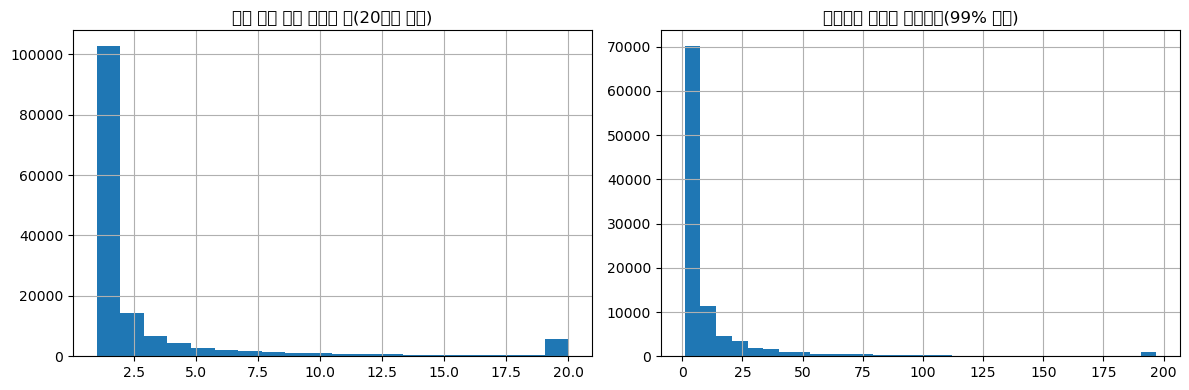

,구분,값
0,직접 관측,"조달일, 품목 행, 수량, 총금액, 참여·낙찰 표시, 공급자 ID"
1,계산 대리변수,"임시 품목군, 단가, 반복참여 간격, 재등장률, 포트폴리오, HHI"
2,별도 시나리오,"WTP, WTA, 공급용량, 배송비, 인센티브 반응, All-or-Nothing"


저장: D:\CODE\proj2\5pl\data\processed\comprasnet\calibration_summary.json


In [10]:
# 핵심 그래프와 보정 요약 JSON을 저장한다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
items_per_auction["item_group_count"].clip(upper=20).hist(ax=axes[0], bins=20)
axes[0].set_title("조달 건별 임시 품목군 수(20에서 절단)")
supplier_summary["item_group_count"].clip(upper=supplier_summary["item_group_count"].quantile(.99)).hist(ax=axes[1], bins=30)
axes[1].set_title("공급자별 품목군 커버리지(99% 절단)")
plt.tight_layout(); plt.savefig(FIGURES / "bundle_and_supplier_coverage.png", dpi=150); plt.show()

interpretation = pd.DataFrame([
    ("직접 관측", "조달일, 품목 행, 수량, 총금액, 참여·낙찰 표시, 공급자 ID"),
    ("계산 대리변수", "임시 품목군, 단가, 반복참여 간격, 재등장률, 포트폴리오, HHI"),
    ("별도 시나리오", "WTP, WTA, 공급용량, 배송비, 인센티브 반응, All-or-Nothing"),
], columns=["구분", "값"])
display(interpretation)
calibration_summary = {
    "seed": SEED,
    "observed": {"auction_rows": int(len(auctions)), "valid_item_rows": int(len(items_valid)),
                 "period_min": str(auctions["result_date"].min()), "period_max": str(auctions["result_date"].max())},
    "proxies": {**network_stats, "median_items_per_auction": float(items_per_auction["item_group_count"].median()),
                "median_repeat_gap_days": None if pd.isna(gap_summary.get("50%")) else float(gap_summary["50%"]),
                "candidate_item_groups": candidates.head(20)["item_group"].tolist()},
    "scenario_only": ["wtp", "wta", "capacity", "delivery_cost", "incentive_response", "all_or_nothing"],
    "limitations": ["item_group은 설명 기반 임시 그룹이며 SKU가 아니다.", "동시출현은 All-or-Nothing의 증거가 아니다.",
                    "재등장은 잔존과 동일하지 않으며 입찰기회 부재를 구분할 수 없다.", "분포 적합은 충분한 상품형 후보에만 제한했다."],
}
with (PROCESSED / "calibration_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(calibration_summary, handle, ensure_ascii=False, indent=2)
print("저장:", PROCESSED / "calibration_summary.json")